In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

In [2]:
!pip install sentence-transformers

In [3]:
words = [
    "ocean", "fire", "forest", "metal", "silence", "explosion",
    "joy", "fear", "anger", "calm",
    "mathematics", "music", "entropy", "love", "war",
    "machine", "dream", "memory", "shadow", "light",
    "gravity", "chaos", "order", "technology", "nature"
]

In [4]:
tem=SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
emb=tem.encode(words,convert_to_tensor=True)

In [6]:
emb.shape

torch.Size([25, 384])

In [7]:
z=emb/emb.norm(dim=1,keepdim=True)

In [8]:
st=z@z.T

In [9]:
st.shape

torch.Size([25, 25])

In [10]:
class ColorProj(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.l=nn.Linear(dim,3)
    def forward(self,x):
        return self.l(x)

In [11]:
mode=ColorProj(z.shape[1])

In [12]:
opt=optim.Adam(mode.parameters(),lr=0.01)

In [13]:
for epoch in range(1000):
    opt.zero_grad()
    col=mode(z)
    col=col/col.norm(dim=1,keepdim=True)
    sc=col@col.T
    loss=torch.mean((st-sc)**2)
    loss.backward()
    opt.step()
    if epoch%100==0:
        print(f'Epoch {epoch}, Loss {loss}')

Epoch 0, Loss 0.28448545932769775
Epoch 100, Loss 0.11793676763772964
Epoch 200, Loss 0.11618762463331223
Epoch 300, Loss 0.11575916409492493
Epoch 400, Loss 0.11552812159061432
Epoch 500, Loss 0.11539725214242935
Epoch 600, Loss 0.1153431162238121
Epoch 700, Loss 0.11532875895500183
Epoch 800, Loss 0.11532504856586456
Epoch 900, Loss 0.11532361060380936


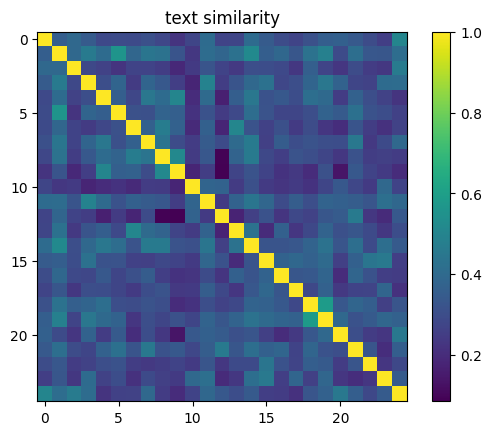

In [14]:
plt.imshow(st.detach().numpy())
plt.title('text similarity')
plt.colorbar()
plt.show()

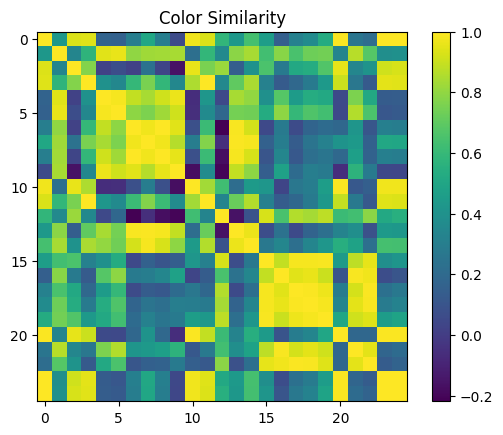

In [15]:
plt.imshow(sc.detach().numpy())
plt.title("Color Similarity")
plt.colorbar()
plt.show()

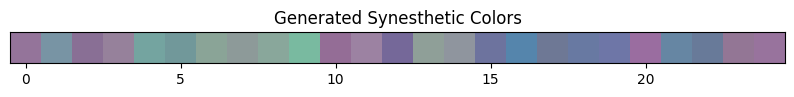

In [19]:
final_colors = mode(z).detach()
final_colors = torch.sigmoid(final_colors)
plt.figure(figsize=(10, 2))
plt.imshow(final_colors.unsqueeze(0).numpy())
plt.title("Generated Synesthetic Colors")
plt.yticks([])
plt.show()

In [20]:
corr = torch.corrcoef(
    torch.stack([st.flatten(), sc.flatten()])
)
print("Similarity correlation:", corr[0,1].item())

Similarity correlation: 0.5352830290794373


In [21]:
from sklearn.decomposition import PCA

In [22]:
pca=PCA(n_components=3)

In [23]:
zpca=torch.tensor(pca.fit_transform(z.numpy()))
zpca=zpca/zpca.norm(dim=1,keepdim=True)

In [24]:
spca=zpca@zpca.T

In [26]:
corr_pca = torch.corrcoef(
    torch.stack([st.flatten(), spca.flatten()])
)[0,1]

print("PCA similarity correlation:", corr_pca.item())

PCA similarity correlation: 0.5590729117393494
